In [1]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


In [2]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

In [3]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

In [4]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


In [5]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


In [6]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


In [13]:
class CNN1D(nn.Module):
    def __init__(self, input_size=1530):
        super(CNN1D, self).__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.flat_size = 128 * (input_size // 16)
        self.fc_layers = nn.Sequential(
            nn.Linear(self.flat_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x.squeeze(1)

print("CNN1D defined!")

CNN1D defined!


In [14]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=50, batch_size=32, lr=1e-4):

    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    X_v  = torch.FloatTensor(X_val).to(device)
    y_v  = torch.FloatTensor(y_val).to(device)

    dataset   = TensorDataset(X_tr, y_tr)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.SmoothL1Loss(beta=0.02)
    optimizer = optim.AdamW(model.parameters(),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(loader),
                    epochs=epochs)

    model.to(device)
    best_val_loss = np.inf
    best_weights  = None
    train_losses  = []
    val_losses    = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(loader)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_v)
            val_loss   = criterion(y_val_pred, y_v).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() 
                            for k, v in model.state_dict().items()}

    model.load_state_dict(best_weights)
    return model, train_losses, val_losses

print("train_model defined!")

train_model defined!


Build Cultivar Level Data:

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_decomposition import PLSRegression
import random

# Apply best preprocessing
X_pre = snv(savitzky_golay_smooth(X))

# Build cultivar level mean spectra and labels
cultivar_mean_spectra = {}
cultivar_labels       = {}
cultivar_all_spectra  = {}

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    if spectra:
        all_intens = [s[1] for s in spectra]
        mean_spec  = np.mean(all_intens, axis=0)
        
        # Apply preprocessing to mean spectrum
        mean_pre = snv(savitzky_golay_smooth(np.array([mean_spec])))[0]
        
        cultivar_mean_spectra[folder_name] = mean_pre
        cultivar_labels[folder_name]       = meta['cys']
        
        # Store all preprocessed spectra for this cultivar
        start = cultivar_names.index(folder_name) * 324
        end   = start + 324
        cultivar_all_spectra[folder_name] = X_pre[start:end]

print(f"Cultivars loaded: {len(cultivar_mean_spectra)}")
print(f"Cysteine range: {min(cultivar_labels.values()):.4f} to {max(cultivar_labels.values()):.4f}")

# Sort cultivars by cysteine value
sorted_by_cys = sorted(cultivar_labels.items(), key=lambda x: x[1])
print("\nCultivars sorted by cysteine:")
for name, cys in sorted_by_cys:
    print(f"  {CULTIVARS[name]['label']:20s} {cys:.4f}")

Cultivars loaded: 20
Cysteine range: 0.3120 to 0.3732

Cultivars sorted by cysteine:
  CDC Meadow           0.3120
  CDC Canary           0.3145
  Redbat 88            0.3163
  AAC Chrome           0.3172
  AAC Liscard          0.3254
  CDC Dakota           0.3328
  CDC Jasper           0.3373
  CDC Patrick          0.3384
  AAC Lacombe          0.3386
  CDC Athabasca        0.3412
  CDC Lewochko         0.3413
  CDC Tetris           0.3420
  CDC Striker          0.3450
  CDC Spruce           0.3457
  CDC Greenwater       0.3464
  CDC Saffron          0.3468
  CDC Amarillo         0.3589
  CDC Golden           0.3591
  CDC Inca             0.3653
  CDC Spectrum         0.3732


In [8]:
def strategy1_cysteine_diversity(n_select=5):
    """
    Select cultivars that cover the full cysteine range
    using percentile based selection
    """
    print("="*50)
    print("STRATEGY 1 — Cysteine Value Diversity")
    print("="*50)
    
    # Sort cultivars by cysteine value
    sorted_cultivars = sorted(cultivar_labels.items(), key=lambda x: x[1])
    names_sorted     = [c[0] for c in sorted_cultivars]
    cys_sorted       = [c[1] for c in sorted_cultivars]
    
    # Select at percentile positions
    # For 5 cultivars: 0%, 25%, 50%, 75%, 100%
    percentiles  = np.linspace(0, len(names_sorted)-1, n_select)
    indices      = [int(round(p)) for p in percentiles]
    selected     = [names_sorted[i] for i in indices]
    
    print(f"\nSelected {n_select} cultivars by cysteine percentile:")
    for i, (idx, cult) in enumerate(zip(indices, selected)):
        percentile = i * 25
        print(f"  {percentile}th percentile: {CULTIVARS[cult]['label']:20s} "
              f"cysteine = {cultivar_labels[cult]:.4f}")
    
    return selected

# Run Strategy 1
selected_s1 = strategy1_cysteine_diversity(n_select=5)
print(f"\nFinal selection: {[CULTIVARS[c]['label'] for c in selected_s1]}")

STRATEGY 1 — Cysteine Value Diversity

Selected 5 cultivars by cysteine percentile:
  0th percentile: CDC Meadow           cysteine = 0.3120
  25th percentile: CDC Dakota           cysteine = 0.3328
  50th percentile: CDC Lewochko         cysteine = 0.3413
  75th percentile: CDC Greenwater       cysteine = 0.3464
  100th percentile: CDC Spectrum         cysteine = 0.3732

Final selection: ['CDC Meadow', 'CDC Dakota', 'CDC Lewochko', 'CDC Greenwater', 'CDC Spectrum']


In [9]:
def evaluate_loco_subset(labeled_cultivars, model_type='svr'):
    """
    Evaluate LOCO performance using only labeled cultivars
    Train on n-1 labeled cultivars, test on held out one
    Repeat for all labeled cultivars
    """
    if len(labeled_cultivars) < 3:
        return None, None, None

    all_true, all_pred = [], []

    for held_out in labeled_cultivars:
        train_set = [c for c in labeled_cultivars if c != held_out]

        X_tr, y_tr = [], []
        for cult in train_set:
            spectra = cultivar_all_spectra[cult]
            X_tr.extend(spectra)
            y_tr.extend([cultivar_labels[cult]] * len(spectra))

        X_te = cultivar_all_spectra[held_out]
        y_te = [cultivar_labels[held_out]] * len(X_te)

        X_tr = np.array(X_tr)
        y_tr = np.array(y_tr)
        X_te = np.array(X_te)

        if model_type == 'svr':
            scaler  = StandardScaler()
            X_tr_s  = scaler.fit_transform(X_tr)
            X_te_s  = scaler.transform(X_te)
            model   = SVR(kernel='rbf', C=100, epsilon=0.001, gamma='auto')
            model.fit(X_tr_s, y_tr)
            pred    = model.predict(X_te_s)

        elif model_type == 'rf':
            model = RandomForestRegressor(
                n_estimators=200, max_depth=None,
                min_samples_split=2, min_samples_leaf=2,
                max_features='sqrt', random_state=42, n_jobs=-1
            )
            model.fit(X_tr, y_tr)
            pred = model.predict(X_te)

        elif model_type == 'cnn':
            torch.manual_seed(42)
            cnn = CNN1D(input_size=1530).to(device)
            cnn, _, _ = train_model(
                model=cnn,
                X_train=X_tr, y_train=y_tr,
                X_val=X_te,   y_val=y_te,
                epochs=50, batch_size=32, lr=1e-4
            )
            cnn.eval()
            with torch.no_grad():
                pred = cnn(
                    torch.FloatTensor(X_te).to(device)
                ).cpu().numpy()

        all_true.extend(y_te)
        all_pred.extend(pred)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse = np.sqrt(mean_squared_error(all_true, all_pred))
    r2   = r2_score(all_true, all_pred)
    rpd  = all_true.std() / rmse if rmse > 0 else 0

    return rmse, r2, rpd

print("LOCO evaluation function defined!")

LOCO evaluation function defined!


In [10]:
def strategy2_spectral_diversity(n_select=5):
    """
    Select cultivars whose mean spectra are most
    different from each other using greedy PCA selection
    """
    print("="*50)
    print("STRATEGY 2 — Spectral Diversity (PCA)")
    print("="*50)

    # Stack all mean spectra
    cult_names = list(cultivar_mean_spectra.keys())
    X_means    = np.array([cultivar_mean_spectra[c] for c in cult_names])

    # Apply PCA to reduce to 10 components
    scaler  = StandardScaler()
    X_scaled = scaler.fit_transform(X_means)
    pca     = PCA(n_components=10)
    X_pca   = pca.fit_transform(X_scaled)

    print(f"PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

    # Greedy farthest point selection
    # Start with cultivar closest to centre of all spectra
    centre     = X_pca.mean(axis=0)
    distances  = np.linalg.norm(X_pca - centre, axis=1)
    first_idx  = np.argmin(distances)  # most central cultivar

    selected_idx  = [first_idx]
    remaining_idx = list(range(len(cult_names)))
    remaining_idx.remove(first_idx)

    print(f"\nFirst selected (most central): "
          f"{CULTIVARS[cult_names[first_idx]]['label']} "
          f"cysteine = {cultivar_labels[cult_names[first_idx]]:.4f}")

    # Greedily add most distant cultivar
    while len(selected_idx) < n_select:
        max_min_dist = -1
        best_idx     = None

        for idx in remaining_idx:
            # Minimum distance to any already selected cultivar
            min_dist = min(
                np.linalg.norm(X_pca[idx] - X_pca[sel])
                for sel in selected_idx
            )
            if min_dist > max_min_dist:
                max_min_dist = min_dist
                best_idx     = idx

        selected_idx.append(best_idx)
        remaining_idx.remove(best_idx)
        print(f"Added (most distant): "
              f"{CULTIVARS[cult_names[best_idx]]['label']:20s} "
              f"cysteine = {cultivar_labels[cult_names[best_idx]]:.4f} "
              f"distance = {max_min_dist:.4f}")

    selected = [cult_names[i] for i in selected_idx]
    print(f"\nFinal selection: {[CULTIVARS[c]['label'] for c in selected]}")
    return selected

# Run Strategy 2
selected_s2 = strategy2_spectral_diversity(n_select=5)

STRATEGY 2 — Spectral Diversity (PCA)
PCA variance explained: 100.0%

First selected (most central): CDC Greenwater cysteine = 0.3464
Added (most distant): AAC Liscard          cysteine = 0.3254 distance = 85.8990
Added (most distant): CDC Saffron          cysteine = 0.3468 distance = 56.6177
Added (most distant): CDC Canary           cysteine = 0.3145 distance = 45.3858
Added (most distant): CDC Meadow           cysteine = 0.3120 distance = 43.4911

Final selection: ['CDC Greenwater', 'AAC Liscard', 'CDC Saffron', 'CDC Canary', 'CDC Meadow']


In [11]:
def strategy3_combination(n_select=5, alpha=0.5):
    """
    Combine cysteine value diversity AND spectral diversity
    alpha = weight for spectral diversity (1-alpha = cysteine diversity)
    """
    print("="*50)
    print("STRATEGY 3 — Combination (Cysteine + Spectral)")
    print("="*50)

    cult_names = list(cultivar_mean_spectra.keys())
    X_means    = np.array([cultivar_mean_spectra[c] for c in cult_names])
    cys_values = np.array([cultivar_labels[c] for c in cult_names])

    # ── Spectral diversity score via PCA ──
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_means)
    pca      = PCA(n_components=10)
    X_pca    = pca.fit_transform(X_scaled)

    # ── Greedy selection combining both scores ──
    centre      = X_pca.mean(axis=0)
    cys_mean    = cys_values.mean()

    # Normalize cysteine values to 0-1
    cys_min  = cys_values.min()
    cys_max  = cys_values.max()
    cys_norm = (cys_values - cys_min) / (cys_max - cys_min)

    # Start with cultivar that is most central spectrally
    # AND closest to mean cysteine
    spectral_dist = np.linalg.norm(X_pca - centre, axis=1)
    cys_dist      = np.abs(cys_norm - 0.5)  # distance from middle cysteine

    # Normalize both distances to 0-1
    spec_norm = spectral_dist / spectral_dist.max()
    cys_d_norm = cys_dist / cys_dist.max()

    # Combined score — lower = more central = start here
    combined_start = alpha * spec_norm + (1 - alpha) * cys_d_norm
    first_idx      = np.argmin(combined_start)

    selected_idx  = [first_idx]
    remaining_idx = list(range(len(cult_names)))
    remaining_idx.remove(first_idx)

    print(f"\nFirst selected (most central combined): "
          f"{CULTIVARS[cult_names[first_idx]]['label']} "
          f"cysteine = {cultivar_labels[cult_names[first_idx]]:.4f}")

    # Greedily add cultivar with highest combined diversity score
    while len(selected_idx) < n_select:
        best_score = -1
        best_idx   = None

        for idx in remaining_idx:
            # Spectral distance from nearest selected cultivar
            spec_d = min(
                np.linalg.norm(X_pca[idx] - X_pca[sel])
                for sel in selected_idx
            )

            # Cysteine distance from nearest selected cultivar
            cys_d = min(
                abs(cys_norm[idx] - cys_norm[sel])
                for sel in selected_idx
            )

            # Normalize
            spec_d_n = spec_d / (X_pca.max() - X_pca.min())
            cys_d_n  = cys_d  # already 0-1

            # Combined score — higher = more diverse
            score = alpha * spec_d_n + (1 - alpha) * cys_d_n

            if score > best_score:
                best_score = score
                best_idx   = idx

        selected_idx.append(best_idx)
        remaining_idx.remove(best_idx)
        print(f"Added: {CULTIVARS[cult_names[best_idx]]['label']:20s} "
              f"cysteine = {cultivar_labels[cult_names[best_idx]]:.4f} "
              f"score = {best_score:.4f}")

    selected = [cult_names[i] for i in selected_idx]
    print(f"\nFinal selection: {[CULTIVARS[c]['label'] for c in selected]}")
    return selected

# Run Strategy 3
selected_s3 = strategy3_combination(n_select=5, alpha=0.5)

STRATEGY 3 — Combination (Cysteine + Spectral)

First selected (most central combined): CDC Tetris cysteine = 0.3420
Added: AAC Liscard          cysteine = 0.3254 score = 0.5175
Added: CDC Spectrum         cysteine = 0.3732 score = 0.3485
Added: CDC Canary           cysteine = 0.3145 score = 0.2712
Added: CDC Golden           cysteine = 0.3591 score = 0.2238

Final selection: ['CDC Tetris', 'AAC Liscard', 'CDC Spectrum', 'CDC Canary', 'CDC Golden']


In [15]:
# Copy CNN1D and train_model from CNN notebook first
# Then run this cell

print("Running LOCO evaluation for all strategies...")

strategies = {
    "Strategy 1 (Cysteine Diversity)": selected_s1,
    "Strategy 2 (Spectral Diversity)": selected_s2,
    "Strategy 3 (Combination)":        selected_s3,
    "Random Baseline":                  random.sample(list(CULTIVARS.keys()), 5)
}

print("Random baseline selection:")
for c in strategies["Random Baseline"]:
    print(f"  {CULTIVARS[c]['label']:20s} cysteine = {cultivar_labels[c]:.4f}")

models_to_test = ['svr', 'rf', 'cnn']
all_results    = {}

for strategy_name, selected in strategies.items():
    print(f"\n{'='*55}")
    print(f"{strategy_name}")
    print(f"Selected: {[CULTIVARS[c]['label'] for c in selected]}")
    print(f"{'='*55}")

    all_results[strategy_name] = {}

    for model_type in models_to_test:
        print(f"\n  Model: {model_type.upper()}")
        rmse, r2, rpd = evaluate_loco_subset(selected, model_type=model_type)
        all_results[strategy_name][model_type] = {
            "rmse": rmse, "r2": r2, "rpd": rpd
        }
        print(f"  LOCO → RMSE: {rmse:.4f}  R²: {r2:.4f}  RPD: {rpd:.4f}")

print("\n ALL EVALUATIONS DONE!")

Running LOCO evaluation for all strategies...
This will take a while on GPU — all 3 models x 4 strategies

Random baseline selection:
  CDC Tetris           cysteine = 0.3420
  AAC Chrome           cysteine = 0.3172
  CDC Jasper           cysteine = 0.3373
  CDC Amarillo         cysteine = 0.3589
  Redbat 88            cysteine = 0.3163

Strategy 1 (Cysteine Diversity)
Selected: ['CDC Meadow', 'CDC Dakota', 'CDC Lewochko', 'CDC Greenwater', 'CDC Spectrum']

  Model: SVR
  LOCO → RMSE: 0.0257  R²: -0.6810  RPD: 0.7713

  Model: RF
  LOCO → RMSE: 0.0259  R²: -0.6977  RPD: 0.7675

  Model: CNN
  LOCO → RMSE: 0.0147  R²: 0.4507  RPD: 1.3492

Strategy 2 (Spectral Diversity)
Selected: ['CDC Greenwater', 'AAC Liscard', 'CDC Saffron', 'CDC Canary', 'CDC Meadow']

  Model: SVR
  LOCO → RMSE: 0.0280  R²: -2.4665  RPD: 0.5371

  Model: RF
  LOCO → RMSE: 0.0267  R²: -2.1574  RPD: 0.5628

  Model: CNN
  LOCO → RMSE: 0.0078  R²: 0.7325  RPD: 1.9334

Strategy 3 (Combination)
Selected: ['CDC Tetris', 

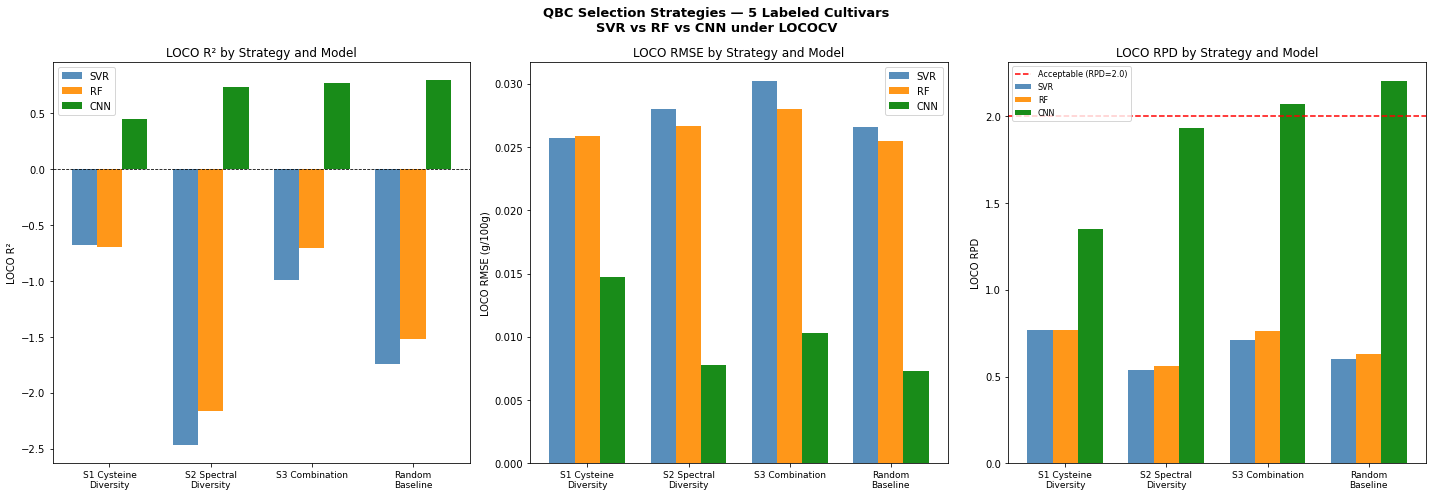


=== CULTIVAR SELECTION SUMMARY ===

Strategy                  Selected Cultivars                                           Cys Range
----------------------------------------------------------------------------------------------------
Strategy 1 (Cysteine Diversity) ['CDC Meadow', 'CDC Dakota', 'CDC Lewochko', 'CDC Greenwater', 'CDC Spectrum'] 0.3120 to 0.3732
Strategy 2 (Spectral Diversity) ['CDC Greenwater', 'AAC Liscard', 'CDC Saffron', 'CDC Canary', 'CDC Meadow'] 0.3120 to 0.3468
Strategy 3 (Combination)  ['CDC Tetris', 'AAC Liscard', 'CDC Spectrum', 'CDC Canary', 'CDC Golden'] 0.3145 to 0.3732
Random Baseline           ['CDC Tetris', 'AAC Chrome', 'CDC Jasper', 'CDC Amarillo', 'Redbat 88'] 0.3163 to 0.3589


In [16]:
import pandas as pd

strategies_names = [
    "S1 Cysteine\nDiversity",
    "S2 Spectral\nDiversity", 
    "S3 Combination",
    "Random\nBaseline"
]

svr_r2  = [-0.6810, -2.4665, -0.9917, -1.7444]
rf_r2   = [-0.6977, -2.1574, -0.7049, -1.5159]
cnn_r2  = [0.4507,   0.7325,  0.7672,  0.7939]
svr_rpd = [0.7713,   0.5371,  0.7086,  0.6036]
rf_rpd  = [0.7675,   0.5628,  0.7659,  0.6304]
cnn_rpd = [1.3492,   1.9334,  2.0725,  2.2026]
svr_rmse = [0.0257,  0.0280,  0.0302,  0.0266]
rf_rmse  = [0.0259,  0.0267,  0.0280,  0.0255]
cnn_rmse = [0.0147,  0.0078,  0.0103,  0.0073]

x     = np.arange(len(strategies_names))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ── R² ──
ax1 = axes[0]
ax1.bar(x - width, svr_r2,  width, color='steelblue',  alpha=0.9, label='SVR')
ax1.bar(x,         rf_r2,   width, color='darkorange',  alpha=0.9, label='RF')
ax1.bar(x + width, cnn_r2,  width, color='green',       alpha=0.9, label='CNN')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xticks(x)
ax1.set_xticklabels(strategies_names, fontsize=9)
ax1.set_ylabel("LOCO R²")
ax1.set_title("LOCO R² by Strategy and Model")
ax1.legend()

# ── RMSE ──
ax2 = axes[1]
ax2.bar(x - width, svr_rmse, width, color='steelblue', alpha=0.9, label='SVR')
ax2.bar(x,         rf_rmse,  width, color='darkorange', alpha=0.9, label='RF')
ax2.bar(x + width, cnn_rmse, width, color='green',      alpha=0.9, label='CNN')
ax2.set_xticks(x)
ax2.set_xticklabels(strategies_names, fontsize=9)
ax2.set_ylabel("LOCO RMSE (g/100g)")
ax2.set_title("LOCO RMSE by Strategy and Model")
ax2.legend()

# ── RPD ──
ax3 = axes[2]
ax3.bar(x - width, svr_rpd, width, color='steelblue', alpha=0.9, label='SVR')
ax3.bar(x,         rf_rpd,  width, color='darkorange', alpha=0.9, label='RF')
ax3.bar(x + width, cnn_rpd, width, color='green',      alpha=0.9, label='CNN')
ax3.axhline(2.0, color='red', linewidth=1.5,
            linestyle='--', label='Acceptable (RPD=2.0)')
ax3.set_xticks(x)
ax3.set_xticklabels(strategies_names, fontsize=9)
ax3.set_ylabel("LOCO RPD")
ax3.set_title("LOCO RPD by Strategy and Model")
ax3.legend(fontsize=8)

plt.suptitle("QBC Selection Strategies — 5 Labeled Cultivars\nSVR vs RF vs CNN under LOCOCV",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("QBC_strategies_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Selected cultivars per strategy ──
print("\n=== CULTIVAR SELECTION SUMMARY ===")
print(f"\n{'Strategy':<25} {'Selected Cultivars':<60} {'Cys Range'}")
print("-"*100)
for sname, sel in strategies.items():
    cys_vals = [cultivar_labels[c] for c in sel]
    cult_labels = [CULTIVARS[c]['label'] for c in sel]
    print(f"{sname:<25} {str(cult_labels):<60} "
          f"{min(cys_vals):.4f} to {max(cys_vals):.4f}")

In [ ]:
Multiple Random Runs:

In [17]:
print("Running 10 random baseline runs...")
random_runs = []

for run in range(10):
    random.seed(run)  # different seed each run
    random_selected = random.sample(list(CULTIVARS.keys()), 5)
    
    run_results = {}
    for model_type in models_to_test:
        rmse, r2, rpd = evaluate_loco_subset(
            random_selected, model_type=model_type
        )
        run_results[model_type] = {"rmse": rmse, "r2": r2, "rpd": rpd}
    
    random_runs.append({
        "run":      run,
        "selected": random_selected,
        "results":  run_results
    })
    print(f"Run {run+1}/10 — CNN R²: {run_results['cnn']['r2']:.4f}  "
          f"SVR R²: {run_results['svr']['r2']:.4f}  "
          f"RF R²:  {run_results['rf']['r2']:.4f}")

# Average results across 10 runs
print("\n=== RANDOM BASELINE — AVERAGED OVER 10 RUNS ===")
for model_type in models_to_test:
    avg_r2   = np.mean([r['results'][model_type]['r2']   for r in random_runs])
    avg_rmse = np.mean([r['results'][model_type]['rmse'] for r in random_runs])
    avg_rpd  = np.mean([r['results'][model_type]['rpd']  for r in random_runs])
    std_r2   = np.std([r['results'][model_type]['r2']    for r in random_runs])
    print(f"{model_type.upper():5s} → RMSE: {avg_rmse:.4f}  "
          f"R²: {avg_r2:.4f} ± {std_r2:.4f}  RPD: {avg_rpd:.4f}")

Running 10 random baseline runs...
Run 1/10 — CNN R²: 0.5557  SVR R²: -2.4314  RF R²:  -1.7415
Run 2/10 — CNN R²: 0.8230  SVR R²: -1.0940  RF R²:  -1.1687
Run 3/10 — CNN R²: 0.7447  SVR R²: 0.1123  RF R²:  -0.2178
Run 4/10 — CNN R²: 0.6405  SVR R²: -1.6287  RF R²:  -1.6528
Run 5/10 — CNN R²: 0.6338  SVR R²: -1.7273  RF R²:  -1.5338
Run 6/10 — CNN R²: 0.7850  SVR R²: -1.2311  RF R²:  -1.0553
Run 7/10 — CNN R²: 0.7781  SVR R²: -1.7278  RF R²:  -0.3854
Run 8/10 — CNN R²: 0.7854  SVR R²: -0.1213  RF R²:  -0.6761
Run 9/10 — CNN R²: 0.6091  SVR R²: -0.9386  RF R²:  -1.0783
Run 10/10 — CNN R²: 0.7755  SVR R²: -0.7546  RF R²:  -0.5853

=== RANDOM BASELINE — AVERAGED OVER 10 RUNS ===
SVR   → RMSE: 0.0204  R²: -1.1542 ± 0.7349  RPD: 0.7207
RF    → RMSE: 0.0195  R²: -1.0095 ± 0.5064  RPD: 0.7239
CNN   → RMSE: 0.0074  R²: 0.7131 ± 0.0887  RPD: 1.9325


Budget Curves:

In [ ]:
budget_sizes = [5, 8, 10, 12, 15]
budget_results = {
    "S1 Cysteine":   {m: [] for m in models_to_test},
    "S2 Spectral":   {m: [] for m in models_to_test},
    "S3 Combination":{m: [] for m in models_to_test},
    "Random":        {m: [] for m in models_to_test},
}

for budget in budget_sizes:
    print(f"\n{'='*50}")
    print(f"Budget: {budget} labeled cultivars")
    print(f"{'='*50}")

    # Strategy 1 — cysteine diversity
    sorted_cultivars = sorted(cultivar_labels.items(), key=lambda x: x[1])
    names_sorted     = [c[0] for c in sorted_cultivars]
    indices          = [int(round(p)) for p in np.linspace(0, len(names_sorted)-1, budget)]
    s1_selected      = [names_sorted[i] for i in indices]

    # Strategy 2 — spectral diversity
    cult_names = list(cultivar_mean_spectra.keys())
    X_means    = np.array([cultivar_mean_spectra[c] for c in cult_names])
    scaler     = StandardScaler()
    X_scaled   = scaler.fit_transform(X_means)
    pca        = PCA(n_components=10)
    X_pca      = pca.fit_transform(X_scaled)
    centre     = X_pca.mean(axis=0)
    distances  = np.linalg.norm(X_pca - centre, axis=1)
    first_idx  = np.argmin(distances)
    s2_idx     = [first_idx]
    remaining  = list(range(len(cult_names)))
    remaining.remove(first_idx)
    while len(s2_idx) < budget:
        best_d, best_i = -1, None
        for idx in remaining:
            d = min(np.linalg.norm(X_pca[idx] - X_pca[s]) for s in s2_idx)
            if d > best_d:
                best_d, best_i = d, idx
        s2_idx.append(best_i)
        remaining.remove(best_i)
    s2_selected = [cult_names[i] for i in s2_idx]

    # Strategy 3 — combination
    cys_values = np.array([cultivar_labels[c] for c in cult_names])
    cys_norm   = (cys_values - cys_values.min()) / (cys_values.max() - cys_values.min())
    spec_dist  = np.linalg.norm(X_pca - centre, axis=1)
    spec_norm  = spec_dist / spec_dist.max()
    cys_d_norm = np.abs(cys_norm - 0.5) / np.abs(cys_norm - 0.5).max()
    combined   = 0.5 * spec_norm + 0.5 * cys_d_norm
    first_idx  = np.argmin(combined)
    s3_idx     = [first_idx]
    remaining  = list(range(len(cult_names)))
    remaining.remove(first_idx)
    while len(s3_idx) < budget:
        best_score, best_i = -1, None
        for idx in remaining:
            spec_d = min(np.linalg.norm(X_pca[idx] - X_pca[s]) for s in s3_idx)
            cys_d  = min(abs(cys_norm[idx] - cys_norm[s]) for s in s3_idx)
            score  = 0.5 * (spec_d / (X_pca.max() - X_pca.min())) + 0.5 * cys_d
            if score > best_score:
                best_score, best_i = score, idx
        s3_idx.append(best_i)
        remaining.remove(best_i)
    s3_selected = [cult_names[i] for i in s3_idx]

    # Random — average of 5 runs
    random_r2   = {m: [] for m in models_to_test}
    for run in range(5):
        random.seed(run)
        rand_sel = random.sample(list(CULTIVARS.keys()), budget)
        for model_type in models_to_test:
            _, r2, _ = evaluate_loco_subset(rand_sel, model_type=model_type)
            if r2 is not None:
                random_r2[model_type].append(r2)

    # Evaluate all strategies
    for strategy_name, selected in [
        ("S1 Cysteine",    s1_selected),
        ("S2 Spectral",    s2_selected),
        ("S3 Combination", s3_selected),
    ]:
        for model_type in models_to_test:
            _, r2, _ = evaluate_loco_subset(selected, model_type=model_type)
            budget_results[strategy_name][model_type].append(r2)
            print(f"  {strategy_name} {model_type.upper():5s} R²: {r2:.4f}")

    for model_type in models_to_test:
        avg_r2 = np.mean(random_r2[model_type]) if random_r2[model_type] else None
        budget_results["Random"][model_type].append(avg_r2)
        print(f"  Random     {model_type.upper():5s} R²: {avg_r2:.4f}")

print("\n BUDGET CURVE DONE!")


Budget: 5 labeled cultivars
  S1 Cysteine SVR   R²: -0.6810
  S1 Cysteine RF    R²: -0.6977
  S1 Cysteine CNN   R²: 0.6117
  S2 Spectral SVR   R²: -2.4665
  S2 Spectral RF    R²: -2.1574
  S2 Spectral CNN   R²: 0.6464
  S3 Combination SVR   R²: -0.9917
  S3 Combination RF    R²: -0.7049
  S3 Combination CNN   R²: 0.5424
  Random     SVR   R²: -1.3538
  Random     RF    R²: -1.2629
  Random     CNN   R²: 0.6758

Budget: 8 labeled cultivars
  S1 Cysteine SVR   R²: -2.2564
  S1 Cysteine RF    R²: -1.4964
  S1 Cysteine CNN   R²: 0.1110
  S2 Spectral SVR   R²: -1.6726
  S2 Spectral RF    R²: -0.5742
  S2 Spectral CNN   R²: 0.5661
  S3 Combination SVR   R²: -1.5709
  S3 Combination RF    R²: -0.7152
  S3 Combination CNN   R²: 0.5159
  Random     SVR   R²: -1.0206
  Random     RF    R²: -0.8510
  Random     CNN   R²: 0.5163

Budget: 10 labeled cultivars
  S1 Cysteine SVR   R²: -1.7636
  S1 Cysteine RF    R²: -0.8613
  S1 Cysteine CNN   R²: 0.8084
  S2 Spectral SVR   R²: -1.6110
  S2 Spectral

True Iterative QBC:

In [ ]:
print("Running True Iterative QBC...")
print("Starts with 3 labeled cultivars, adds one at a time using disagreement\n")

# Start with 3 cultivars — one low, one mid, one high cysteine
sorted_cultivars = sorted(cultivar_labels.items(), key=lambda x: x[1])
names_sorted     = [c[0] for c in sorted_cultivars]
initial_labeled  = [names_sorted[0],   # lowest cysteine
                    names_sorted[9],   # middle cysteine
                    names_sorted[-1]]  # highest cysteine

labeled_set   = initial_labeled.copy()
unlabeled_set = [c for c in CULTIVARS.keys() if c not in labeled_set]

qbc_iterative_results = []

print(f"Initial labeled set:")
for c in labeled_set:
    print(f"  {CULTIVARS[c]['label']:20s} cysteine = {cultivar_labels[c]:.4f}")

# Evaluate initial
rmse, r2, rpd = evaluate_loco_subset(labeled_set, model_type='cnn')
qbc_iterative_results.append({
    "n_labeled": len(labeled_set),
    "added":     "Initial",
    "r2":        r2,
    "rmse":      rmse,
    "rpd":       rpd
})
print(f"\nInitial CNN LOCO — R²: {r2:.4f}  RMSE: {rmse:.4f}")

# Iterative QBC loop
while len(unlabeled_set) > 0 and len(labeled_set) < 15:
    print(f"\n--- Step: {len(labeled_set)} labeled, {len(unlabeled_set)} unlabeled ---")

    # Train committee on labeled set
    X_tr, y_tr = [], []
    for cult in labeled_set:
        spectra = cultivar_all_spectra[cult]
        X_tr.extend(spectra)
        y_tr.extend([cultivar_labels[cult]] * len(spectra))

    X_tr = np.array(X_tr)
    y_tr = np.array(y_tr)

    # Train SVR
    scaler_svr  = StandardScaler()
    X_tr_s      = scaler_svr.fit_transform(X_tr)
    svr_model   = SVR(kernel='rbf', C=100, epsilon=0.001, gamma='auto')
    svr_model.fit(X_tr_s, y_tr)

    # Train RF
    rf_model = RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    )
    rf_model.fit(X_tr, y_tr)

    # Train CNN
    torch.manual_seed(42)
    cnn_model = CNN1D(input_size=1530).to(device)
    cnn_model, _, _ = train_model(
        model=cnn_model,
        X_train=X_tr, y_train=y_tr,
        X_val=X_tr,   y_val=y_tr,
        epochs=50, batch_size=32, lr=1e-4
    )

    # Compute disagreement for each unlabeled cultivar
    disagreements = {}
    for cult in unlabeled_set:
        X_cult = cultivar_all_spectra[cult]

        svr_pred = svr_model.predict(scaler_svr.transform(X_cult))
        rf_pred  = rf_model.predict(X_cult)
        cnn_model.eval()
        with torch.no_grad():
            cnn_pred = cnn_model(
                torch.FloatTensor(X_cult).to(device)
            ).cpu().numpy()

        preds         = np.stack([svr_pred, rf_pred, cnn_pred], axis=0)
        disagreements[cult] = np.std(preds, axis=0).mean()
        print(f"  {CULTIVARS[cult]['label']:20s} disagreement: {disagreements[cult]:.5f}")

    # Select highest disagreement cultivar
    next_cult = max(disagreements, key=disagreements.get)
    labeled_set.append(next_cult)
    unlabeled_set.remove(next_cult)
    print(f"\nSelected: {CULTIVARS[next_cult]['label']} "
          f"(disagreement: {disagreements[next_cult]:.5f})")

    # Evaluate CNN LOCO
    rmse, r2, rpd = evaluate_loco_subset(labeled_set, model_type='cnn')
    qbc_iterative_results.append({
        "n_labeled": len(labeled_set),
        "added":     CULTIVARS[next_cult]['label'],
        "r2":        r2,
        "rmse":      rmse,
        "rpd":       rpd
    })
    print(f"CNN LOCO — R²: {r2:.4f}  RMSE: {rmse:.4f}  RPD: {rpd:.4f}")

print("\n ITERATIVE QBC DONE!")

All Plots Together:

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
colors = {'S1 Cysteine': 'steelblue', 'S2 Spectral': 'darkorange',
          'S3 Combination': 'green', 'Random': 'red'}

# ── Plot 1: Budget curve CNN R² ──
ax1 = axes[0]
for strategy_name in budget_results:
    r2_values = budget_results[strategy_name]['cnn']
    ax1.plot(budget_sizes, r2_values, 'o-',
             color=colors[strategy_name],
             linewidth=2, markersize=6,
             label=strategy_name)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel("Number of Labeled Cultivars")
ax1.set_ylabel("LOCO R²")
ax1.set_title("Budget Curve — CNN LOCO R²\nvs Number of Labels")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Strategy comparison at 5 labels ──
ax2 = axes[1]
strategies_plot = ["S1 Cysteine\nDiversity", "S2 Spectral\nDiversity",
                   "S3 Combination", "Random\nBaseline"]
x = np.arange(len(strategies_plot))
width = 0.25
ax2.bar(x - width, svr_r2,  width, color='steelblue',  alpha=0.9, label='SVR')
ax2.bar(x,         rf_r2,   width, color='darkorange',  alpha=0.9, label='RF')
ax2.bar(x + width, cnn_r2,  width, color='green',       alpha=0.9, label='CNN')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(strategies_plot, fontsize=8)
ax2.set_ylabel("LOCO R²")
ax2.set_title("Strategy Comparison at 5 Labels\nSVR vs RF vs CNN")
ax2.legend()

# ── Plot 3: Iterative QBC curve ──
ax3 = axes[2]
n_labeled = [r['n_labeled'] for r in qbc_iterative_results]
r2_values = [r['r2']        for r in qbc_iterative_results]
ax3.plot(n_labeled, r2_values, 'o-',
         color='purple', linewidth=2, markersize=6,
         label='QBC Iterative')
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax3.axhline(0.6, color='green', linewidth=1.5,
            linestyle='--', label='Target R²=0.6')
ax3.set_xlabel("Number of Labeled Cultivars")
ax3.set_ylabel("CNN LOCO R²")
ax3.set_title("Iterative QBC — CNN Performance\nvs Labels Added")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.suptitle("QBC Active Learning — Complete Analysis",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("QBC_complete_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# Print iterative QBC selection order
print("\n=== ITERATIVE QBC SELECTION ORDER ===")
print(f"{'Step':<6} {'Added':<25} {'N Labeled':>10} {'CNN R²':>10} {'CNN RMSE':>12}")
print("-"*65)
for r in qbc_iterative_results:
    r2_str   = f"{r['r2']:.4f}"   if r['r2']   is not None else "N/A"
    rmse_str = f"{r['rmse']:.4f}" if r['rmse'] is not